# **Spiking Neural Networks (SNNs) com PyTorch e snnTorch**

**Autora:** Gisela Ceresér Kassick

**Professor orientador:** Daniel R. Cassar

*Abril, 2026*

---

Este notebook oferece uma introdução prática e teórica às Redes Neurais Pulsadas (Spiking Neural Networks - SNNs). Baseado nos tutoriais oficiais do snnTorch, exploraremos desde os fundamentos até o treinamento de redes fully-connected para classificação de dígitos MNIST.

---
# 1. Um pouco de teoria...

## 1.1. O que é uma SNN?
FONTES: ESHRAGHIAN et al, 2021; YAMAZAKI et al, 2022.

Redes Neurais Artificiais (ANNs) tradicionais operam com valores contínuos e realizam cálculos em cada camada de forma síncrona. As **Spiking Neural Networks (SNNs)** representam uma evolução das ANNs ao incorporarem a dimensão temporal, se assemelhando ao processo biológico de transmissão de informação.

Em vez de transmitir valores contínuos, os neurônios em uma SNN se comunicam por meio de **pulsos (spikes)** — eventos binários e discretos no tempo. Um neurônio dispara um pulso (valor 1) quando seu potencial de membrana atinge um determinado **limiar**; caso contrário, permanece em silêncio (valor 0).

A Figura 1 ilustra o fluxo de informação em uma SNN. A entrada é uma sequência temporal de pulsos binários, representando a ativação dos neurônios ao longo do tempo. Esses pulsos percorrem as sinapses, onde são ponderados por **pesos ajustáveis** ($W$), que determinam a força de cada conexão. No dendrito, ocorre a **integração** desses sinais ponderados, gerando uma corrente que influencia o potencial de membrana do neurônio. Quando esse potencial ultrapassa um limiar predefinido, o neurônio **dispara**, produzindo um pulso de saída — também representado como uma sequência binária. Esse processo se repete em cada camada da rede, permitindo que a SNN aprenda padrões temporais e espaciais nos dados, aproveitando a informação contida tanto na presença quanto na ausência dos pulsos.

![Diagrama SNN](Imagem1.jpg)

<center>
<small>
Figura 1. Diagrama de uma SNN.  
FONTE: Adaptado de YAMAZAKI et al., 2022.
</small>
</center>


**Características fundamentais:**
*   **Computação baseada em eventos**: Processamento ocorre apenas quando há pulsos, resultando em alta eficiência energética
*   **Dinâmica temporal**: Informação é processada ao longo do tempo, não apenas em um único passo 
*   **Plausibilidade biológica**: Modelos matemáticos simplificados de neurônios reais.

## 1.2. Funcionamento
FONTES: ESHRAGHIAN et al, 2021.

O base do funcionamento de uma SNN é o modelo de neurônio. O modelo mais comum é o **Leaky Integrate-and-Fire (LIF) Neuron**. 

A Figura 2 apresenta um diagrama esquemático do modelo LIF, que emula o comportamento de um neurônio biológico por meio de um circuito elétrico equivalente. Nele, a corrente de entrada $I_{in}$ carrega um capacitor ($C$), representando o acúmulo de carga no potencial de membrana, enquanto um resistor ($R$) introduz o efeito de vazamento (leak), permitindo que o potencial decaia ao longo do tempo. Quando a tensão $V$ atinge o limiar $V_{thr}$, ocorre o disparo, que é representado pelo pico no gráfico temporal, seguido pelo reset do potencial. Esse circuito captura de forma simplificada a dinâmica de integração, vazamento e disparo que define o neurônio LIF.

![Figura 2](Imagem2.jpg)

<center>
<small>
Figura 2. Modelo do neurônio LIF (Leaky Integrate-and-Fire). À esquerda, o circuito elétrico equivalente: a corrente de entrada ($I_{in}$) carrega o capacitor ($C$), representando a integração, enquanto o resistor ($R$) introduz o vazamento (leak) do potencial de membrana. À direita, a evolução temporal do potencial de membrana ($V$) ao longo do tempo: o potencial aumenta com a corrente de entrada até atingir o limiar ($V_{thr}$), momento em que ocorre o disparo (spike), seguido pelo reset do potencial. O gráfico mostra como $V$ se comporta como uma "integração com vazamento" até o disparo.
Fonte: ESHRAGHIAN et al., 2021.
</small>
</center>

Seu funcionamento pode ser descrito em três etapas:

1.  **Integração**: O neurônio soma as correntes de entrada (provenientes de pulsos de neurônios anteriores ou da codificação de dados) ao longo do tempo, aumentando seu **potencial de membrana** ($U[t]$).

2.  **Vazamento (Leak)**: Ao longo do tempo, se não houver estímulos, o potencial de membrana decai naturalmente. Isso é modelado por um fator de decaimento $\beta$.

3.  **Disparo (Fire)**: Quando o potencial de membrana atinge ou ultrapassa um **limiar (threshold)**, o neurônio gera um pulso de saída (spike). Após o disparo, o potencial de membrana é resetado (tipicamente para zero) para dar início a um novo ciclo.

Matematicamente, para cada passo de tempo $t$, o processo é:

$$
U[t+1] = \underbrace{\beta U[t]}_{\text{decaimento}} + \underbrace{I_{\text{in}}[t]}_{\text{entrada}} - \underbrace{S_{\text{out}}[t] \cdot U_{\text{reset}}}_{\text{reset}}
$$

$$
S_{\text{out}}[t] = \Theta(U[t] - U_{\text{thr}}) = \begin{cases} 1 & \text{se } U[t] > U_{\text{thr}} \\ 0 & \text{caso contr\'ario} \end{cases}
$$

Onde $U[t]$ é o potencial de membrana no tempo $t$, $I_{\text{in}}[t]$ é a corrente de entrada, e $S_{\text{out}}[t]$ é o pulso de saída, e $\Theta(\cdot)$ é a função degrau de Heaviside.

## 1.3. O Desafio da Não-Diferenciabilidade

FONTES: ESHRAGHIAN et al, 2021.

### O Problema

Para treinar redes neurais com backpropagation, precisamos de gradientes. A função degrau $\Theta(\cdot)$ tem derivada nula em quase todos os pontos:

$$
\frac{\partial S}{\partial U} = \delta(U - U_{\text{thr}}) =
\begin{cases}
\infty & \text{se } U = U_{\text{thr}} \\
0 & \text{caso contr\'ario}
\end{cases}
$$

Na regra da cadeia, isso anula o gradiente:

$$
\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial S} \cdot \underbrace{\frac{\partial S}{\partial U}}_{\{0, \infty\}} \cdot \frac{\partial U}{\partial I} \cdot \frac{\partial I}{\partial W}
$$

A Figura 3 nos mostra graficamente esse problema: enquanto a função degrau (Heaviside) é utilizada no forward pass para gerar os spikes binários, sua derivada é zero em quase toda a extensão, exceto no ponto de descontinuidade onde tende ao infinito. Isso significa que, durante a retropropagação, o gradiente se anula para a maioria dos valores de potencial de membrana, impedindo a atualização dos pesos e inviabilizando o aprendizado.

![Figura 3](Imagem3.jpg)

<center>
<small>
Figura 3. Comparação entre a função degrau (Heaviside) e sua derivada. Enquanto a função original gera os spikes binários, sua derivada é nula em quase todos os pontos, causando o desaparecimento do gradiente.
Fonte: Adaptado de ESHRAGHIAN et al., 2021.
</small>
</center>



**Consequência**: Gradiente zero → pesos não atualizados → rede não aprende.

### A Solução: Gradientes Substitutos (Surrogate Gradients)

A técnica moderna substitui a derivada da função degrau por uma função suave durante o backward pass, mantendo a função original no forward pass.

O snnTorch utiliza a função arco tangente como aproximação:

$$
\frac{\partial \tilde{S}}{\partial U} \leftarrow \frac{1}{\pi} \cdot \frac{1}{1 + (\pi U)^2}
$$

Esta função é suave, contínua e fornece gradientes não-nulos em todos os pontos.

## 1.4. Desafios Adicionais das SNNs

FONTES: ESHRAGHIAN et al, 2021; SVOBODA et al, 2026; YAMAZAKI et al, 2022.

1. **Codificação de Dados**: Dados contínuos precisam ser convertidos em sequências de pulsos
2. **Complexidade Temporal**: Simulação ao longo de múltiplos passos de tempo aumenta custo computacional
3. **Sensibilidade a Hiperparâmetros**: $\beta$, threshold e timesteps afetam diretamente a dinâmica da rede

## 1.5. Aplicações e Comparação com ANNs

FONTES: ESHRAGHIAN et al, 2021; YAMAZAKI et al, 2022.

**Principais aplicações:**
- Visão computacional de baixo consumo (câmeras de eventos)
- Processamento de sinais neurais (EEG, ECoG)
- Robótica e controle em tempo real
- Computação neuromórfica (Intel Loihi, IBM TrueNorth)

**Comparação ANNs vs SNNs:**

| Característica | ANN | SNN |
| :--- | :--- | :--- |
| Unidade de Processamento | Valor contínuo | Pulso binário |
| Dimensão Temporal | Estático | Dinâmico |
| Função de Ativação | Suave e diferenciável | Degrau (não-diferenciável) |
| Treinamento | Backprop padrão | Backprop com surrogate gradient |
| Eficiência Energética | Baixa | Alta (event-based) |

<center>
<small>
Tabela 1. Comparação entre ANN e SNN.  
FONTE: Autora.
</small>
</center>

## 1.6. Hiperparâmetros em SNNs

FONTES: ESHRAGHIAN et al, 2021; HOSSAIN et al, 2025.

Em SNNs, os hiperparâmetros desempenham um papel ainda mais crítico do que em ANNs, pois afetam diretamente a dinâmica temporal dos neurônios. A escolha adequada desses parâmetros é essencial para o sucesso do treinamento.

### Principais Hiperparâmetros

| Hiperparâmetro | Símbolo | Descrição | Efeito | Valor Típico |
|----------------|---------|-----------|--------|--------------|
| **Beta (β)** | $\beta$ | Fator de decaimento do potencial de membrana | Controla a "memória" do neurônio | 0.8 - 0.99 |
| **Threshold** | $U_{\text{thr}}$ | Limiar de disparo | Define quando o neurônio dispara | 0.5 - 1.5 |
| **Timesteps** | $T$ | Número de passos de tempo da simulação | Afeta precisão e custo computacional | 20 - 100 |
| **Learning Rate** | $\eta$ | Taxa de aprendizado | Controla a magnitude das atualizações | 1e-4 - 1e-2 |
| **Surrogate Slope** | $\alpha$ | Inclinação do gradiente substituto | Controla a suavidade da aproximação | 10 - 100 |

<center>
<small>
Tabela 2. Principais hiperparâmetros de uma SNN.  
FONTE: Autora.
</small>
</center>

É importante notar que os hiperparâmetros não são independentes. Algumas interações importantes:

- β alto + threshold alto: Neurônios podem nunca disparar

- β baixo + threshold baixo: Spikes excessivos, rede instável

- Poucos timesteps + threshold alto: Nenhum aprendizado (poucos spikes)

- Learning rate alta + slope alto: Gradientes instáveis, divergência


## 1.7. Arquiteturas de SNNs

FONTES: ESHRAGHIAN, 2021; LI, 2021; SVOBODA et al, 2026.

Assim como nas ANNs tradicionais, as SNNs podem ser implementadas com diversas arquiteturas. Cada arquitetura tem suas vantagens e desvantagens, sendo mais adequada para diferentes tipos de problemas.

**Fully-Connected (FCN-SNN)**:
- Conexões entre todos os neurônios de camadas adjacentes
- Simples, ideal para prototipagem
- Não preserva estrutura espacial

**Convolutional (CNN-SNN)**:
- Camadas convolucionais preservam estrutura espacial
- Menos parâmetros, melhor para imagens
- Maior acurácia em tarefas de visão

**Recorrentes (RNN-SNN)**:
- Conexões de retroalimentação
- Ideais para séries temporais e dados sequenciais

**Híbridas**:
- Combinação de camadas ANN (codificação) e SNN (processamento)
- Aproveitam o melhor de ambos os mundos

Neste notebook, implementaremos **FCN-SNN** para classificação do dataset MNIST.

---
# 2. Setup e Dependências para a construção de um SNN

FONTES: ESHRAGHIAN et al, 2021.

In [1]:
# Importando as bibliotecas necessárias
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import spikegen, surrogate
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# Define o uso do CPU para processamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cpu


---
# 3. Preparando o dataset MNIST

FONTES: ESHRAGHIAN et al, 2021.

**Características:**
- 60.000 imagens de treino, 10.000 de teste
- 28x28 pixels em escala de cinza
- 10 classes (dígitos 0-9)

MNIST é ideal para introdução às SNNs por ser simples, permitir comparação com literatura e ter baixa complexidade computacional. Por isso, será o dataset utilizado neste notebook.

Treino: 60000 imagens
Teste: 10000 imagens


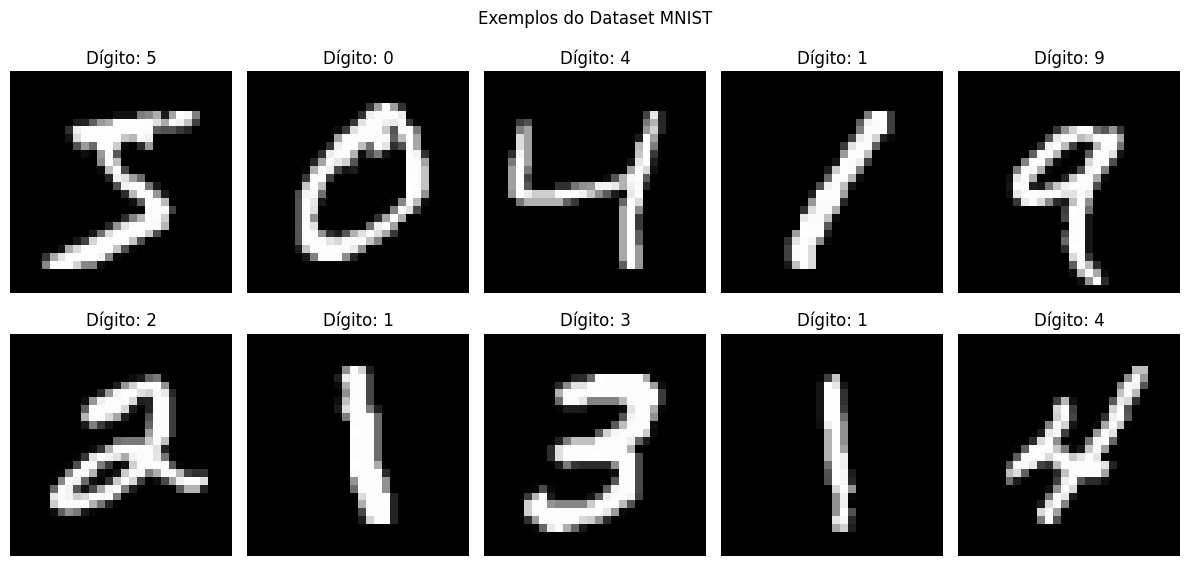

In [2]:
# Carrega e prepara o dataset MNIST com 60k imagens de treino e 10k de teste, normalizando os pixels para o intervalo [0,1]
# Observação: MNIST possui apenas divisão oficial entre treino (60k) e teste (10k). Para validação, geralmente separa-se uma parte do treino (ex: 10%) ou usa-se validação cruzada

batch_size = 128
data_path = '/tmp/data/mnist'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

print(f"Treino: {len(mnist_train)} imagens")
print(f"Teste: {len(mnist_test)} imagens")

# Visualização
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = mnist_train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Dígito: {label}')
    ax.axis('off')
plt.suptitle('Exemplos do Dataset MNIST')
plt.tight_layout()
plt.show()

---
# 4. Como representar os dados em spikes?

FONTES: ESHRAGHIAN et al, 2021.

O primeiro passo para usar uma SNN é transformar dados contínuos em sequências de pulsos. Existem várias técnicas, sendo as mais comuns:
*   **Rate Coding (Codificação por Taxa)**: A intensidade do valor é representada pela frequência de pulsos ao longo do tempo. Valores altos geram mais pulsos.
*   **Latency Coding (Codificação por Latência)**: A intensidade é representada pelo tempo do primeiro pulso. Valores altos disparam mais cedo.
*   **Delta Modulation**: Gera pulsos quando a diferença entre o valor atual e o anterior ultrapassa um limiar.

Vamos usar o **Rate Coding**, que é simples e eficaz, implementado pela função `spikegen.rate`.

Valor do pixel central: 0.925


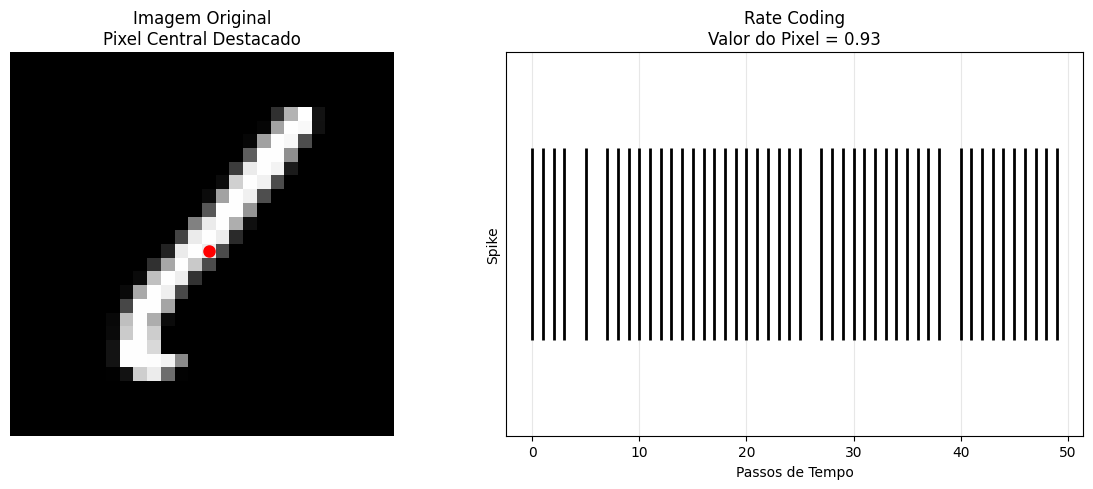


Resultado do Rate Coding:
- Total de spikes: 46 spikes
- Frequência de disparo: 0.92 spikes/timestep
- Valor do pixel: 0.93
- Relação: quanto maior o valor do pixel, mais spikes são gerados


In [3]:
# Converte um valor contínuo (pixel) em spikes ao longo do tempo
num_steps_demo = 50
sample_data, _ = next(iter(train_loader))
sample_img = sample_data[0].view(28, 28)
sample_pixel_value = sample_img[14, 14].item()  # Pixel central

print(f"Valor do pixel central: {sample_pixel_value:.3f}")

# Gera spikes com frequência proporcional ao valor do pixel (Rate Coding)
rate_spikes = spikegen.rate(torch.tensor([sample_pixel_value]), num_steps=num_steps_demo).squeeze()

# Compara a imagem original com a codificação em spikes do pixel central
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagem original com destaque no pixel central
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Imagem Original\nPixel Central Destacado')
axes[0].axis('off')
# Destacar o pixel central
axes[0].plot(14, 14, 'ro', markersize=8)

# Spike Train do Rate Coding - mostra como o valor do pixel é convertido em padrão temporal de spikes
axes[1].eventplot([np.where(rate_spikes.numpy() == 1)[0]], colors='black', linewidths=2)
axes[1].set_title(f'Rate Coding\nValor do Pixel = {sample_pixel_value:.2f}')
axes[1].set_xlabel('Passos de Tempo')
axes[1].set_ylabel('Spike')
axes[1].set_ylim(0, 2)
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nResultado do Rate Coding:")
print(f"- Total de spikes: {rate_spikes.sum().item():.0f} spikes")
print(f"- Frequência de disparo: {rate_spikes.sum().item()/num_steps_demo:.2f} spikes/timestep")
print(f"- Valor do pixel: {sample_pixel_value:.2f}")
print(f"- Relação: quanto maior o valor do pixel, mais spikes são gerados")

---
# 5. Demonstração do Neurônio LIF

FONTES: ESHRAGHIAN et al, 2021.

Antes de construir redes completas, vamos observar o comportamento de um único neurônio LIF com corrente constante.

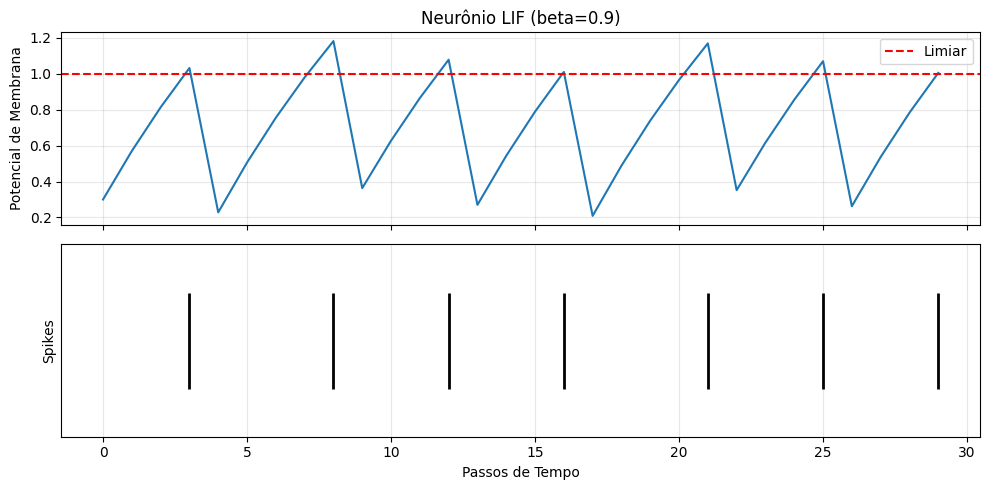

Total de spikes: 7.0
Frequência de disparo: 0.23 spikes/timestep


In [4]:
# Demonstra o comportamento do neurônio LIF (Leaky Integrate-and-Fire) com corrente constante de entrada
beta = 0.9
threshold = 1.0
num_steps_lif = 30

lif = snn.Leaky(beta=beta, threshold=threshold)
mem = lif.init_leaky()

spk_rec, mem_rec = [], []
input_current = torch.tensor(0.3)

# Simula o neurônio ao longo do tempo: integra corrente, decai e dispara quando atinge o limiar
for step in range(num_steps_lif):
    spk, mem = lif(input_current, mem)
    spk_rec.append(spk.item())
    mem_rec.append(mem.item())

# Visualização: gráfico superior mostra o potencial de membrana, inferior mostra os spikes gerados
fig, ax = plt.subplots(2, figsize=(10, 5), sharex=True)

ax[0].plot(mem_rec)
ax[0].axhline(threshold, linestyle='--', color='r', label='Limiar')
ax[0].set_ylabel('Potencial de Membrana')
ax[0].legend()
ax[0].set_title(f'Neurônio LIF (beta={beta})')
ax[0].grid(True, alpha=0.3)

spike_positions = [i for i, s in enumerate(spk_rec) if s == 1]
ax[1].eventplot(spike_positions, colors='black', linewidths=2)
ax[1].set_ylabel('Spikes')
ax[1].set_xlabel('Passos de Tempo')
ax[1].set_ylim(0, 2)
ax[1].set_yticks([])
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total de spikes: {sum(spk_rec)}")
print(f"Frequência de disparo: {sum(spk_rec)/num_steps_lif:.2f} spikes/timestep")

---
# 6. Como Treinar uma SNN

FONTES: ESHRAGHIAN et al, 2021.

O treinamento é a parte mais desafiadora devido à não-diferenciabilidade do spike. A solução padrão é usar **Gradientes Substitutos (Surrogate Gradients)**. O truque é:
*   **Forward Pass**: A função de disparo real (degrau) é usada para determinar se um spike ocorre ou não.
*   **Backward Pass**: A derivada da função de disparo é *substituída* pela derivada de uma função suave e aproximada (como uma sigmoide ou uma função arctan). Isso permite que os gradientes fluam através do neurônio e os pesos sejam atualizados.

Vamos construir uma rede simples de duas camadas e treiná-la em uma tarefa de regressão simples. O loop de treinamento em SNNs é diferente: ele percorre os passos de tempo (`num_steps`) e acumula a saída ao longo do tempo.

## 6.1. Definindo a Rede Neural Pulsada

Nossa rede será: `Entrada -> Camada Linear -> LIF -> Camada Linear -> LIF`.

In [5]:
# Hiperparâmetros da rede
num_inputs = 3
num_hidden = 5
num_outputs = 2
beta = 0.9
threshold = 1.0

# Definindo o gradiente substituto (surrogate gradient)
# fast_sigmoid é uma aproximação suave da função degrau
spike_grad = surrogate.fast_sigmoid(slope=25)

# Definindo as camadas
fc1 = nn.Linear(num_inputs, num_hidden)
lif1 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad)

fc2 = nn.Linear(num_hidden, num_outputs)
lif2 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, output=True)  # output=True indica que é a última camada

# Função forward que simula a rede ao longo do tempo
def forward_pass(snn_input, num_steps):
    # Inicializa os estados de memória para ambos os neurônios
    mem1 = lif1.init_leaky()
    mem2 = lif2.init_leaky()

    # Lista para armazenar os spikes de saída
    spk2_rec = []

    for step in range(num_steps):
        # Obtém a entrada do passo de tempo atual
        x = snn_input[step]

        # Camada 1
        cur1 = fc1(x)
        spk1, mem1 = lif1(cur1, mem1)

        # Camada 2
        cur2 = fc2(spk1)
        spk2, mem2 = lif2(cur2, mem2)

        spk2_rec.append(spk2)

    return torch.stack(spk2_rec)

print("Rede definida com sucesso!")
print(f"Estrutura: {num_inputs} → {num_hidden} → {num_outputs}")

Rede definida com sucesso!
Estrutura: 3 → 5 → 2


## 6.2. Loop de Treinamento

Vamos gerar um conjunto de dados sintético e treinar a rede para que sua saída (pulsos) corresponda a um alvo desejado. Lembre-se: a saída são pulsos, mas a função de perda pode ser calculada sobre a média ou soma dos pulsos ao longo do tempo.

Iniciando treinamento...
Epoch  0, Loss: 0.9500
Epoch  5, Loss: 0.9333
Epoch 10, Loss: 0.9333
Epoch 15, Loss: 0.9333
Treinamento concluído!


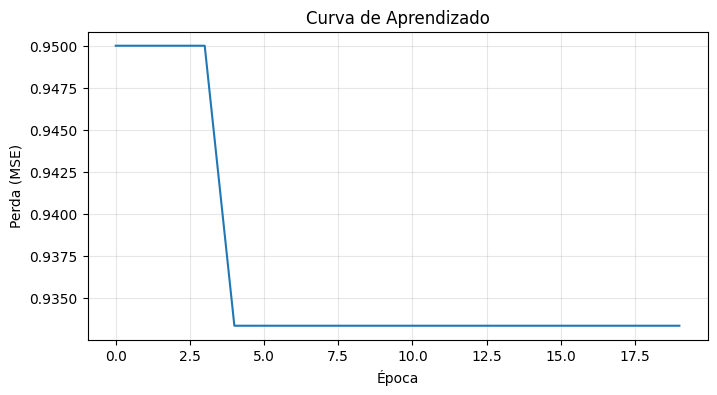

In [6]:
# Gerando dados de entrada: spikes aleatórios para 3 neurônios de entrada ao longo do tempo
num_steps_train = 30
# Simula dados de entrada aleatórios (0 ou 1) com 10% de chance de spike
data_input = (torch.rand(num_steps_train, num_inputs) > 0.9).float()

# Definindo um alvo: queremos que a saída da rede, somada ao longo do tempo, seja um vetor de uns
# Alvo para cada passo de tempo: [1, 1]
target_per_step = torch.ones((num_steps_train, num_outputs))

# Função de perda e otimizador
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(list(fc1.parameters()) + list(fc2.parameters()), lr=1e-3)

# Loop de treinamento
num_epochs = 20
loss_hist = []

print("Iniciando treinamento...")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Obtém a saída da SNN para todos os timesteps
    output_spikes = forward_pass(data_input, num_steps_train)

    # Calcula a perda comparando a saída (spikes) com o alvo
    loss = loss_fn(output_spikes, target_per_step)

    # Retropropagação e atualização dos pesos
    loss.backward()
    optimizer.step()

    loss_hist.append(loss.item())

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d}, Loss: {loss.item():.4f}")
        
print("Treinamento concluído!")

# Plot da curva de perda
plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.xlabel('Época')
plt.ylabel('Perda (MSE)')
plt.title('Curva de Aprendizado')
plt.grid(True, alpha=0.3)
plt.show()

## 6.3. Como Interpretar os Dados de Saída de uma SNN

A saída de uma SNN é uma sequência de pulsos. Para usá-la para uma tarefa de classificação ou regressão, precisamos transformar essa sequência em uma decisão. Os métodos mais comuns são:

1.  **Codificação por Taxa (Rate Coding)**: Contar o número total de pulsos para cada neurônio de saída ao longo de todos os timesteps. O neurônio com a maior contagem de pulsos é a classe predita.
2.  **Codificação por Latência (Latency Coding)**: Analisar o tempo do primeiro pulso. O neurônio que dispara primeiro define a classe.
3.  **Decodificação por Potencial de Membrana**: Utilizar o potencial de membrana final ou médio, que contém informações integradas ao longo do tempo.

Vamos visualizar a saída da nossa rede após o treinamento e aplicar a decodificação por taxa.

Contagem de Spikes por Neurônio de Saída: [4. 0.]


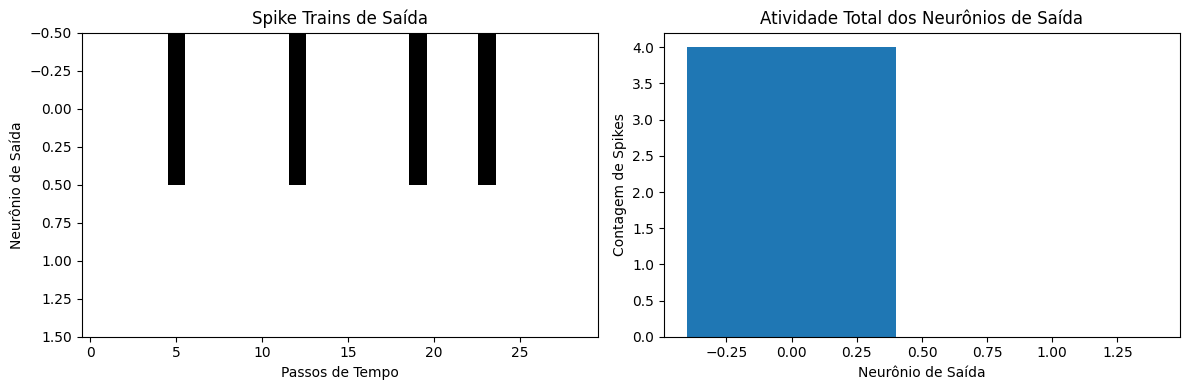

In [7]:
# Obtendo a saída da rede treinada
with torch.no_grad():
    final_output_spikes = forward_pass(data_input, num_steps_train)

# 1. Decodificação por Taxa: Soma os spikes ao longo do tempo
spike_count = final_output_spikes.sum(dim=0)  # soma na dimensão temporal
print("Contagem de Spikes por Neurônio de Saída:", spike_count.numpy())

# 2. Visualizando os spikes de saída
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot dos spikes de saída
ax[0].imshow(final_output_spikes.T, aspect='auto', cmap='binary', interpolation='none')
ax[0].set_title('Spike Trains de Saída')
ax[0].set_xlabel('Passos de Tempo')
ax[0].set_ylabel('Neurônio de Saída')

# Plot da contagem total de spikes (atividade)
ax[1].bar(range(num_outputs), spike_count.numpy())
ax[1].set_title('Atividade Total dos Neurônios de Saída')
ax[1].set_xlabel('Neurônio de Saída')
ax[1].set_ylabel('Contagem de Spikes')

plt.tight_layout()
plt.show()

É interessante notar que esta rede simples treinada não teve bons resultados, o que é indicado tanto pelos gráficos acima, onde era esperado que ambos os neurônios apresentassem valor de spikes próximos a 30, como pela curva de perda que, considerando o valor que estamos trabalhando na rede (0 ou 1), resultou em um valor alto ($\approx 0,93$). Diversos fatores podem contribuir para esse resultado, mas os mais válidos de destacar são a falta de complexidade da rede (poucas camadas e neurônios) diante a tarefa  aser realizada (transformar dados esparsos em uma saída densa e totalmente ativa); e um número relativamente baixo de épocas.

---
# 7. Efeito dos Hiperparâmetros

FONTES: HOSSAIN et al, 2025.

Vamos visualizar como diferentes valores de hiperparâmetros afetam o comportamento do neurônio LIF.

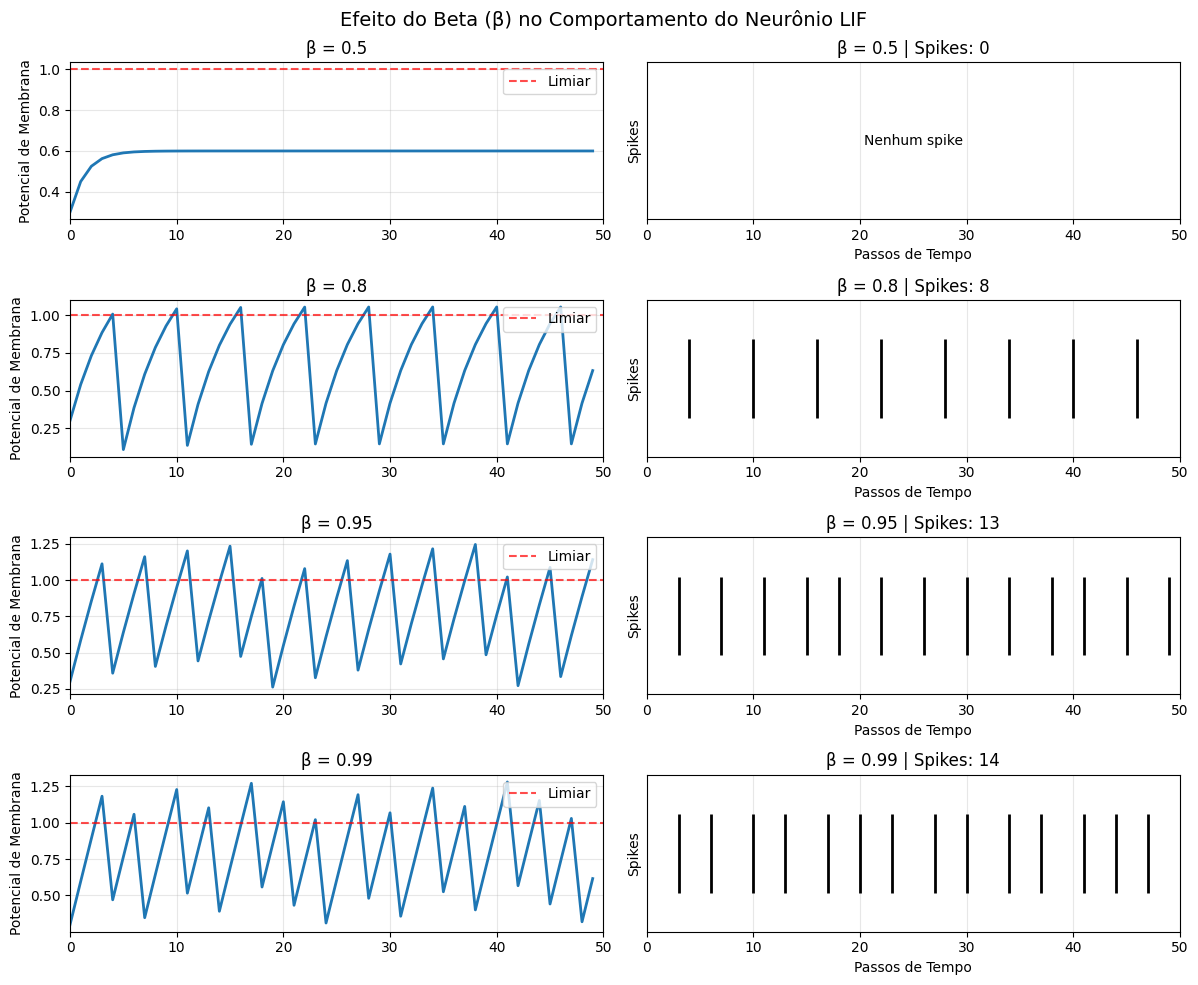

OBSERVAÇÕES SOBRE O EFEITO DO BETA (β)
β = 0.5   → Potencial decai rapidamente. Poucos spikes, memória curta.
β = 0.8   → Equilíbrio entre decaimento e integração. Atividade moderada.
β = 0.95  → Potencial acumula lentamente. Disparos regulares, boa memória.
β = 0.99  → Integração de longo prazo. Muitos spikes, pode saturar.

Interpretação:
- Quanto maior o β, maior a 'memória' do neurônio
- β próximo de 1: o neurônio integra informações por mais tempo
- β próximo de 0: o neurônio esquece rapidamente informações passadas


In [8]:
# Comparando diferentes valores de beta
betas = [0.5, 0.8, 0.95, 0.99]
threshold = 1.0
input_current = torch.tensor(0.3)
num_steps_hyper = 50

fig, axes = plt.subplots(len(betas), 2, figsize=(12, 10))

for idx, beta in enumerate(betas):
    # Criar neurônio LIF
    lif = snn.Leaky(beta=beta, threshold=threshold)
    mem = lif.init_leaky()
    spk_rec, mem_rec = [], []
    
    # Simulação
    for step in range(num_steps_hyper):
        spk, mem = lif(input_current, mem)
        spk_rec.append(spk.item())
        mem_rec.append(mem.item())
    
    # Potencial de membrana
    axes[idx, 0].plot(mem_rec, linewidth=2)
    axes[idx, 0].axhline(threshold, linestyle='--', color='r', alpha=0.7, label='Limiar')
    axes[idx, 0].set_ylabel('Potencial de Membrana')
    axes[idx, 0].set_title(f'β = {beta}')
    axes[idx, 0].set_xlim(0, num_steps_hyper)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].legend(loc='upper right')
    
    # Spikes - verifica se há spikes para plotar
    spike_positions = [i for i, s in enumerate(spk_rec) if s == 1]
    
    if spike_positions:
        axes[idx, 1].eventplot(spike_positions, colors='black', linewidths=2)
    else:
        axes[idx, 1].text(0.5, 0.5, 'Nenhum spike', ha='center', va='center', transform=axes[idx, 1].transAxes)
    
    axes[idx, 1].set_ylabel('Spikes')
    axes[idx, 1].set_title(f'β = {beta} | Spikes: {len(spike_positions)}')
    axes[idx, 1].set_xlabel('Passos de Tempo')
    axes[idx, 1].set_xlim(0, num_steps_hyper)
    axes[idx, 1].set_ylim(0, 2)
    axes[idx, 1].set_yticks([])
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Efeito do Beta (β) no Comportamento do Neurônio LIF', fontsize=14)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES SOBRE O EFEITO DO BETA (β)")
print("="*50)
print("β = 0.5   → Potencial decai rapidamente. Poucos spikes, memória curta.")
print("β = 0.8   → Equilíbrio entre decaimento e integração. Atividade moderada.")
print("β = 0.95  → Potencial acumula lentamente. Disparos regulares, boa memória.")
print("β = 0.99  → Integração de longo prazo. Muitos spikes, pode saturar.")
print("\nInterpretação:")
print("- Quanto maior o β, maior a 'memória' do neurônio")
print("- β próximo de 1: o neurônio integra informações por mais tempo")
print("- β próximo de 0: o neurônio esquece rapidamente informações passadas")

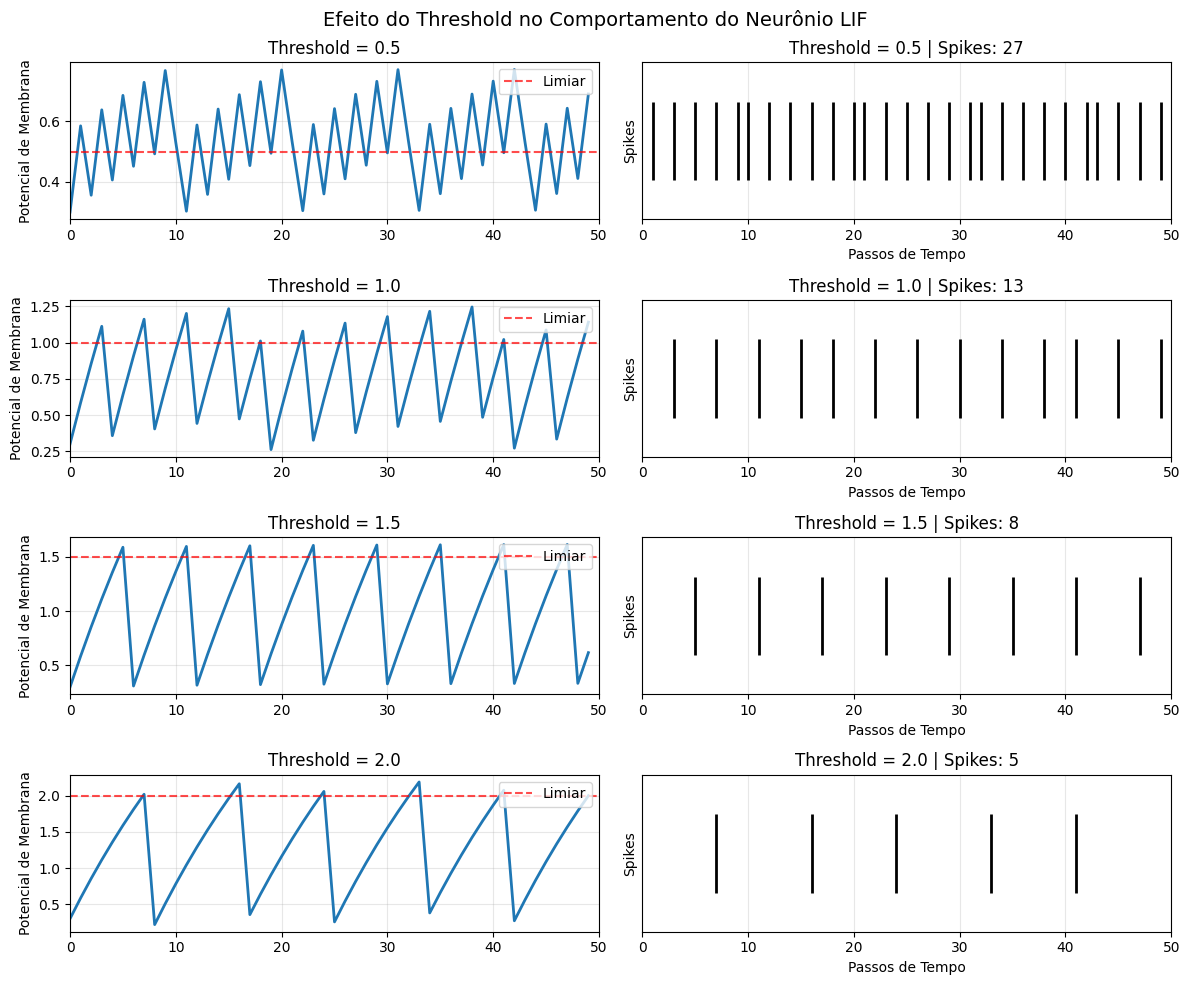

OBSERVAÇÕES SOBRE O EFEITO DO THRESHOLD
Threshold = 0.5 → Disparos frequentes, neurônio muito sensível.
Threshold = 1.0 → Equilíbrio, atividade moderada.
Threshold = 1.5 → Poucos spikes, neurônio mais seletivo.
Threshold = 2.0 → Nenhum spike, neurônio pode 'morrer' (nunca dispara).

Interpretação:
- Quanto menor o threshold, mais sensível é o neurônio
- Quanto maior o threshold, mais difícil é o neurônio disparar
- Threshold muito alto pode levar a neurônios mortos (sem aprendizado)
- Threshold muito baixo pode levar a atividade excessiva (ruído)


In [9]:
# Comparando diferentes valores de threshold
thresholds = [0.5, 1.0, 1.5, 2.0]
beta = 0.95
input_current = torch.tensor(0.3) 
num_steps_hyper = 50

import snntorch as snn
import matplotlib.pyplot as plt
import torch

fig, axes = plt.subplots(len(thresholds), 2, figsize=(12, 10))

for idx, th in enumerate(thresholds):
    lif = snn.Leaky(beta=beta, threshold=th)
    mem = lif.init_leaky()
    spk_rec, mem_rec = [], []
    
    for step in range(num_steps_hyper):
        spk, mem = lif(input_current, mem)
        spk_rec.append(spk.item())
        mem_rec.append(mem.item())
    
    # Potencial de membrana
    axes[idx, 0].plot(mem_rec, linewidth=2)
    axes[idx, 0].axhline(th, linestyle='--', color='r', alpha=0.7, label='Limiar')
    axes[idx, 0].set_ylabel('Potencial de Membrana')
    axes[idx, 0].set_title(f'Threshold = {th}')
    axes[idx, 0].set_xlim(0, num_steps_hyper)
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].legend(loc='upper right')
    
    # Spikes
    spike_positions = [i for i, s in enumerate(spk_rec) if s == 1]
    
    if spike_positions:
        axes[idx, 1].eventplot(spike_positions, colors='black', linewidths=2)
    else:
        axes[idx, 1].text(0.5, 0.5, 'Nenhum spike', ha='center', va='center', transform=axes[idx, 1].transAxes)
    
    axes[idx, 1].set_ylabel('Spikes')
    axes[idx, 1].set_title(f'Threshold = {th} | Spikes: {len(spike_positions)}')
    axes[idx, 1].set_xlabel('Passos de Tempo')
    axes[idx, 1].set_xlim(0, num_steps_hyper)
    axes[idx, 1].set_ylim(0, 2)
    axes[idx, 1].set_yticks([])
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Efeito do Threshold no Comportamento do Neurônio LIF', fontsize=14)
plt.tight_layout()
plt.show()

print("OBSERVAÇÕES SOBRE O EFEITO DO THRESHOLD")
print("="*50)
print("Threshold = 0.5 → Disparos frequentes, neurônio muito sensível.")
print("Threshold = 1.0 → Equilíbrio, atividade moderada.")
print("Threshold = 1.5 → Poucos spikes, neurônio mais seletivo.")
print("Threshold = 2.0 → Nenhum spike, neurônio pode 'morrer' (nunca dispara).")
print("\nInterpretação:")
print("- Quanto menor o threshold, mais sensível é o neurônio")
print("- Quanto maior o threshold, mais difícil é o neurônio disparar")
print("- Threshold muito alto pode levar a neurônios mortos (sem aprendizado)")
print("- Threshold muito baixo pode levar a atividade excessiva (ruído)")

---
# 8. SNN Fully-Connected (FCN-SNN) para MNIST

FONTES: ESHRAGHIAN et al, 2021; LI et al, 2025.

Agora vamos construir uma SNN com camadas totalmente conectadas para classificação MNIST.

Arquitetura: `Entrada (784) → Linear(784→500) → LIF → Linear(500→10) → LIF (saída)`

A camada de entrada recebe uma imagem de 28×28 pixels achatada em um vetor de 784 valores de intensidade, que são codificados em pulsos (spikes) ao longo do tempo. Esse vetor é então passado para a primeira camada linear, que possui 500 neurônios, conectando cada um dos 784 pixels a todos os 500 neurônios ocultos através de pesos ajustáveis. Em seguida, a primeira camada de neurônios LIF (Leaky Integrate-and-Fire) processa essas entradas temporalmente, acumulando potencial de membrana e disparando pulsos quando o limiar é atingido. A saída desses pulsos alimenta a segunda camada linear, que reduz a dimensão para 10 neurônios (um para cada dígito de 0 a 9). Por fim, a segunda camada LIF gera os pulsos de saída, onde a classe com maior contagem de pulsos ao longo do tempo (decodificação por taxa) é a previsão da rede. 

In [10]:
num_inputs = 28 * 28    # 28x28 pixels
num_hidden = 500        # Número de neurônios na camada oculta
num_outputs = 10        # 10 classes (digits 0-9)
num_steps = 25          # Número de passos de tempo que a rede simula para processar uma única entrada (25 intervalos temporais)
beta = 0.95             # Fator de decaimentoMembrane potential decay factor (leak rate)
threshold = 1.0         # Limiar
lr = 5e-4               # Learning rate

# GRADIENTE SUBSTITUTO (sigmoid)
# slope=25: controla a inclinação da função sigmoid usada como gradiente substituto
spike_grad = surrogate.fast_sigmoid(slope=25)

# FULLY CONNECTED SPIKING NEURAL NETWORK
class FCN_SNN(nn.Module):

    def __init__(self):
        super().__init__()                      # Inicializa a classe nn.Module
        self.fc1 = nn.Linear(num_inputs, num_hidden)  # Camada totalmente conectada: 784 entradas em 500 saídas (correntes)
        self.lif1 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad)  # Primeira camada LIF: neurônios com vazamento que geram spikes
        self.fc2 = nn.Linear(num_hidden, num_outputs)  # Segunda camada FC: transforma 500 spikes em 10 correntes de saída
        self.lif2 = snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, output=True)  # Camada LIF de saída
    
    def forward(self, x):
        mem1 = self.lif1.init_leaky()            # Inicializa potencial de membrana da camada oculta com zero
        mem2 = self.lif2.init_leaky()            # Inicializa potencial de membrana da camada de saída com zero
        spk2_rec, mem2_rec = [], []              # Listas para armazenar spikes e potenciais ao longo do tempo
    
        spikes = spikegen.rate(x, num_steps=num_steps)  # Converte cada valor de entrada em um trem de spikes com duração de 'num_steps' passos de tempo (25 no total)
    
    for step in range(num_steps):            # Itera sobre cada passo de tempo (25 passos no total)
        cur1 = self.fc1(spikes[step])        # Calcula corrente de entrada para camada oculta a partir dos spikes do passo atual
        spk1, mem1 = self.lif1(cur1, mem1)   # Atualiza neurônios ocultos: gera spikes e atualiza potencial de membrana
        cur2 = self.fc2(spk1)                # Calcula corrente de entrada para camada de saída a partir dos spikes ocultos
        spk2, mem2 = self.lif2(cur2, mem2)   # Atualiza neurônios de saída: gera spikes e atualiza potencial de membrana
        spk2_rec.append(spk2)                # Armazena spikes de saída deste passo de tempo
        mem2_rec.append(mem2)                # Armazena potenciais de membrana de saída deste passo de tempo
    
    return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)  # Empilha resultados ao longo da dimensão temporal


# INSTANTIATE THE NETWORK
fcn_net = FCN_SNN().to(device)                  # Cria instância da rede e move para o dispositivo
print(f"Parâmetros FCN: {sum(p.numel() for p in fcn_net.parameters()):,}")  # Exibe total de parâmetros treináveis: 397,510

Parâmetros FCN: 397,510


In [11]:
def compute_accuracy(net, data_loader, device):
    net.eval()                                          # Coloca a rede em modo de avaliação
    total, correct = 0, 0                               # Inicializa contadores de total de amostras e acertos
    with torch.no_grad():                               # Desativa cálculo de gradientes para economizar memória e processamento
        for data, targets in data_loader:               # Itera sobre cada lote do data loader
            data = data.view(data.size(0), -1).to(device)   # Achata as imagens (784 ao invés de 28x28) e envia para o dispositivo
            targets = targets.to(device)                # Envia os rótulos para o dispositivo
            spk_rec, _ = net(data)                      # Forward pass: obtém spikes de saída [num_steps, batch, 10]
            _, predicted = spk_rec.sum(dim=0).max(1)    # Soma spikes ao longo do tempo e pega classe com mais spikes
            total += targets.size(0)                    # Acumula total de amostras no lote
            correct += (predicted == targets).sum().item()  # Acumula número de predições corretas
    return correct / total                              # Retorna acurácia (acertos / total)

optimizer = torch.optim.Adam(fcn_net.parameters(), lr=lr)  # Otimizador Adam
loss_fn = nn.CrossEntropyLoss()                         # Função de perda: entropia cruzada para classificação multiclasse

num_epochs = 3                                          # Número de épocas de treinamento
fcn_losses, fcn_accuracies = [], []                     # Listas para armazenar perdas e acurácias ao longo do treinamento

print("Treinando FCN-SNN para MNIST")                  
print("=" * 50)                                         

start_time = time.time()                                # Marca o tempo inicial para medir duração total

for epoch in range(num_epochs):                         # Loop sobre cada época de treinamento
    fcn_net.train()                                     # Coloca a rede em modo de treinamento (ativa gradientes)
    total_loss = 0                                      # Inicializa perda total da época
    for data, targets in train_loader:                  # Itera sobre cada lote do dataset de treinamento
        data = data.view(data.size(0), -1).to(device)   # Achata as imagens e envia para o dispositivo
        targets = targets.to(device)                    # Envia rótulos para o dispositivo
        spk_rec, mem_rec = fcn_net(data)                # Forward pass: obtém spikes e potenciais de membrana
        
        loss_val = torch.zeros(1, device=device)        # Inicializa tensor de perda acumulada
        # Por que somar a perda de cada passo de tempo?
        for step in range(num_steps):                           # Para cada um dos 25 passos temporais
            loss_val += loss_fn(mem_rec[step], targets)         # Acumula perda baseada no potencial de membrana de cada passo
        
        # Isso permite que a rede aprenda a gerar potenciais de membrana apropriados ao longo de todo o tempo, não apenas no último passo
        
        optimizer.zero_grad()                           # Zera gradientes acumulados do otimizador
        loss_val.backward()                             # Calcula gradientes via backpropagation
        optimizer.step()                                # Atualiza pesos da rede
        total_loss += loss_val.item()                   # Acumula perda total do lote
    
    fcn_losses.append(total_loss / len(train_loader))   # Armazena perda média da época
    acc = compute_accuracy(fcn_net, test_loader, device) # Calcula acurácia no dataset de teste
    fcn_accuracies.append(acc)                          # Armazena acurácia da época
    print(f"Epoch {epoch+1} | Perda: {fcn_losses[-1]:.4f} | Acurácia: {acc*100:.2f}%")

elapsed_time = time.time() - start_time                 
print(f"\nTempo total: {elapsed_time:.2f}s")            # Exibe tempo total

Treinando FCN-SNN para MNIST
Epoch 1 | Perda: 10.9681 | Acurácia: 94.44%
Epoch 2 | Perda: 5.3503 | Acurácia: 96.42%
Epoch 3 | Perda: 3.8170 | Acurácia: 97.15%

Tempo total: 416.07s


---
# 9. Visualização dos Resultados dos Treinamentos

Vamos visualizar as curvas de perda e acurácia para ambas as arquiteturas durante o treinamento.

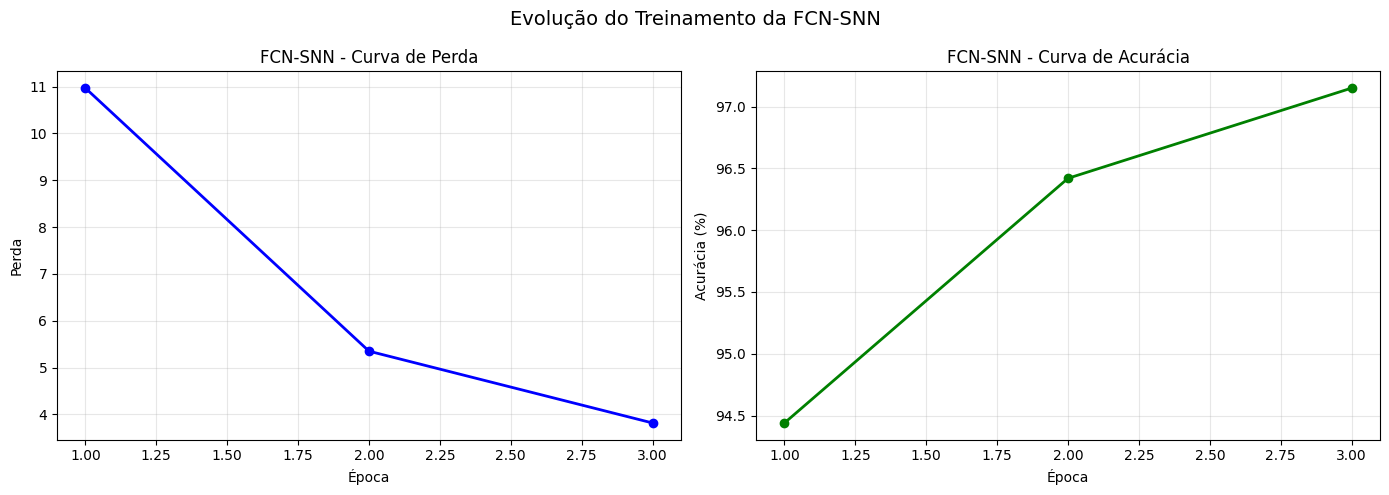

In [12]:
# Configuração dos gráficos para FCN-SNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FCN-SNN: Perda por época
axes[0].plot(range(1, len(fcn_losses) + 1), fcn_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Perda')
axes[0].set_title('FCN-SNN - Curva de Perda')
axes[0].grid(True, alpha=0.3)

# FCN-SNN: Acurácia por época
axes[1].plot(range(1, len(fcn_accuracies) + 1), [a*100 for a in fcn_accuracies], 'g-o', linewidth=2, markersize=6)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].set_title('FCN-SNN - Curva de Acurácia')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolução do Treinamento da FCN-SNN', fontsize=14)
plt.tight_layout()
plt.show()

---
# 10. Conclusão

Neste notebook, exploramos as Redes Neurais Spiking (SNNs), compreendendo conceitos como o modelo de neurônio LIF, o desafio da não-diferenciabilidade dos spikes e aprendenda a implementar uma SNN com o SNNtorch. 

Há um vasto campo de possibilidades para expandir este estudo. É possível implementar arquiteturas mais avançadas, como redes recorrentes pulsadas (RNN-SNN) para processamento de séries temporais, arquiteturas híbridas que combinam camadas ANN para codificação com camadas SNN para processamento eficiente, e até mesmo explorar modelos de neurônios de segunda ordem que capturam dinâmicas temporais mais complexas. A aplicação em datasets de eventos representaria um passo natural, aproveitando a eficiência energética das SNNs para processamento em tempo real. Por fim, a implementação em hardware neuromórfico, permitiria explorar todo o potencial de baixo consumo energético que torna as SNNs tão promissoras para aplicações em dispositivos de baixo recurso.

---
## Referências

- ESHRAGHIAN, Jason K et al. Training spiking neural networks using lessons from deep learning. arXiv preprint, arXiv:2109.12894v6, 2023. Disponível em: https://arxiv.org/abs/2109.12894. Acesso em: 26 mar. 2026.

- HOSSAIN, Mohammad Rubaiyat Tanvir; JOY, Md. Shafiul Islam; CHOWDHURY, Mohammed Hasibul Hasan. A spiking neural network approach for classifying hand movement and relaxation from EEG signal using time domain features. SEAS Transactions on Biology and Biomedicine, v. 22, 2025. DOI: https://doi.org/10.37394/23208.2025.22.16.

- LI, Wei et al. Radar emitter identification based on fully connected spiking neural network. Journal of Physics: Conference Series, v. 1914, p. 012036, 2021. DOI: https://doi.org/10.1088/1742-6596/1914/1/012036.

- SVOBODA, Kama; ADEGBIJA, Tosiron. Spiking Neural Network Architecture Search: A Survey. ArXiv:2510.14235, 2025.
Disponível em: https://arxiv.org/abs/2510.14235. Acesso em: 26 mar. 2026.
.
- YAMAZAKI, Kashu; VO-HO, Viet-Khoa; BULSARA, Darshan; LE, Ngan. Spiking neural networks and their applications: a review. Brain Sciences, v. 12, n. 7, p. 863, 2022. DOI: https://doi.org/10.3390/brainsci12070863.